# Fixed Income Analytics in Python

This notebook implements core fixed income concepts using Python.

The objective is to combine CFA fixed-income theory with practical Python implementation.

### Key Features
- Bond pricing using discounted cash flows
- Premium / Discount / Par bond classification
- Price vs Yield visualization
- Macaulay duration calculation
- Modified duration calculation
- Convexity calculation
- Estimated bond price effect from yield changes
- Duration approximation vs actual bond price comparison chart

### Tools Used
- Python
- NumPy → numerical calculations
- Matplotlib → charts and visualization
- Jupyter Notebook

In [68]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Bond Pricing Function

A bond price equals the present value of all future cash flows discounted at the yield to maturity.

In [61]:
def bond_price(face_value, coupon_rate, ytm, years, frequency=1):

    coupon = face_value * coupon_rate / frequency
    periods = years * frequency
    r = ytm/frequency

    t = np.arange(1,periods+1)
    price = np.sum(coupon / (1+r)**t) + face_value / (1+r)**periods

    return price

## Example Bond Price Calculation

In [62]:
price = bond_price(1000,0.08,.10,5)
print("Bond Price:", round(price,2))

if price > 1000:
    print("Premium Bond")
elif price < 1000:
    print("Discount Bond")
else:
    print("Par Bond")

Bond Price: 924.18
Discount Bond


## 3. Price vs Yield Relationship

Bond prices move inversely to yields.  
This section visualizes the price-yield relationship.

In [63]:
yields= np.linspace(0.01,0.10,50)
prices = []

for y in yields:
    price = bond_price(1000,0.08,y,20)
    prices.append(price)

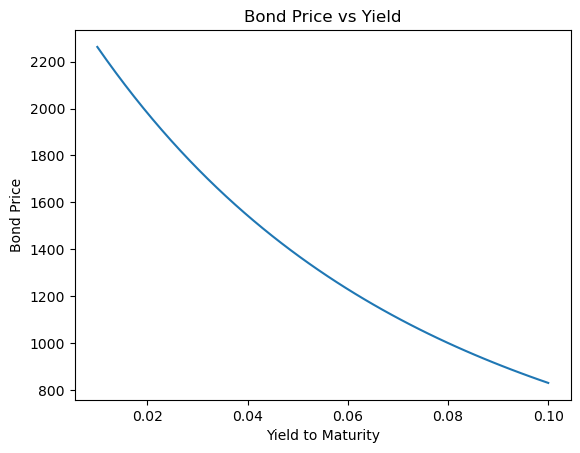

In [64]:
plt.plot(yields,prices)

plt.xlabel("Yield to Maturity")
plt.ylabel("Bond Price")
plt.title("Bond Price vs Yield")

plt.show()

## 5. Final Bond Analytics Function
This function calculates bond price, Macaulay duration, modified duration, convexity, and the estimated price effect from a yield change.

In [71]:
def bond_analytics(face_value, coupon_rate,ytm,years,delta_y=0):
    t= np.arange(1,years+1)

    coupon = face_value * coupon_rate

    cashflows = np.full(years,coupon)
    cashflows [-1] += face_value

    pv = cashflows / (1+ytm)**t
    price = pv.sum()

    macaulay = (t*pv).sum() / price 
    
    modified = macaulay / (1+ytm)
    pct_change = -modified * delta_y
    estimated_price = price * (1+pct_change)

    convexity = (pv * t * (t+1)).sum() / (price * (1+ytm)**2)

    return price, macaulay, modified, pct_change, estimated_price, convexity


## 6. Example: Price Effect of a Yield Change including bond price, Macaulay duration, modified duration and convexity calculation.
Using modified duration, we estimate the percentage change in bond price when yield changes.

In [73]:
price, mac, mod, pct, est_price,conv = bond_analytics(1000, 0.08, 0.10, 5, 0.01)

print("Price:", round (price,2))
print("Macaulay Duration:", round(mac,4))
print("Modified Duration:", round(mod,4))
print("Estimated % Price Change:",round(pct*100,2),"%")
print("Estimated New Price:", round(est_price, 2))
print("Convexity:", round(conv, 4))

Price: 924.18
Macaulay Duration: 4.2814
Modified Duration: 3.8922
Estimated % Price Change: -3.89 %
Estimated New Price: 888.21
Convexity: 20.0973


## 9. Duration Estimate vs Actual Bond Price

Modified duration estimates how bond prices change when yields change.

In this section we compare:

- Actual bond price (calculated using the bond pricing formula)
- Duration-based estimated price

This demonstrates why duration is only an approximation and why convexity improves accuracy.

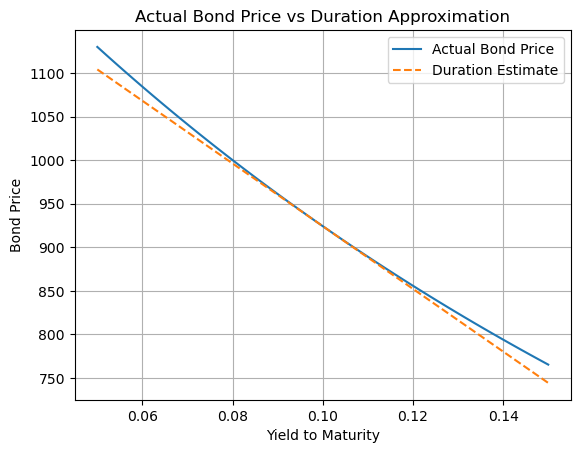

In [74]:
yields = np.linspace (0.05,0.15,50)

actual_prices = []
duration_prices = []

# Base bond analytics at initial yield
price, mac, mod, pct, est_price,conv = bond_analytics(1000, 0.08, 0.10, 5, 0.01)

for y in yields:

    #Actual price
    actual = bond_price(1000,0.08,y,5)

    #Duration estimate
    delta_y = y - 0.10
    pct_change = -mod *delta_y
    duration_est = price * (1+pct_change)

    actual_prices.append(actual)
    duration_prices.append(duration_est)

plt.plot(yields, actual_prices, label="Actual Bond Price")
plt.plot(yields, duration_prices, linestyle="--", label="Duration Estimate")

plt.xlabel("Yield to Maturity")
plt.ylabel("Bond Price")
plt.title("Actual Bond Price vs Duration Approximation")
plt.legend()
plt.grid(True)
